# Coin (Biased Dice) Experiments

In [1]:
import torch
torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

In [ ]:
import icl.utils.notebook_utils as nu
from icl.utils.unified_interface import get_exp_name

#MAJOR_MEANS = [1.5, 2.5, 3.5]
#VOCAB_SIZE = 6
#POOL_TYPE = "partition"

#exp_name = get_exp_name("coin", k=-1, vocab_size=VOCAB_SIZE, major_pool_type=POOL_TYPE, major_means=MAJOR_MEANS)
#_, sampler, _ = nu.load_everything("coin", exp_name)

#print(f"Number of major tasks: {sampler.n_major_tasks}")
#print(f"Vocab size (faces):    {sampler.num_states}")
#print(f"\nmajor_p  (K_maj × V) — probability of each face under each task:")
#print(sampler.major_p)

Number of major tasks: 3
Vocab size (faces):    6

major_p  (K_maj × V) — probability of each face under each task:
tensor([[0.4000, 0.2400, 0.0900, 0.0900, 0.0900, 0.0900],
        [0.0900, 0.0900, 0.3200, 0.3200, 0.0900, 0.0900],
        [0.0900, 0.0900, 0.0900, 0.0900, 0.2400, 0.4000]], device='cuda:0')


## Bayesian posterior over tasks

Each task $k$ defines a categorical distribution over $V$ symbols with probability vector $\mathbf{p}_k = (p_k(0), \ldots, p_k(V{-}1))$. Since tokens are i.i.d. given $k$, the likelihood of an observed sequence $x_{1:t}$ factorizes as

$$P(x_{1:t} \mid Z=k) = \prod_{v=0}^{V-1} p_k(v)^{n_v^{(t)}}$$

where $n_v^{(t)} = \sum_{\tau=1}^t \mathbf{1}[x_\tau = v]$ is the count of symbol $v$ in the first $t$ tokens.

The task pool has $K_{\mathrm{maj}}$ major tasks and $K_{\mathrm{min}}$ minor tasks with prior

$$\pi_k = \begin{cases} (1 - p_0) / K_{\mathrm{maj}} & k \in \text{major}, \\ p_0 / K_{\mathrm{min}} & k \in \text{minor}, \end{cases}$$

where $p_0$ = `p_minor` (default 0.1). When there are no minor tasks, the prior is uniform over major tasks.

Applying Bayes' rule:

$$P(Z=k \mid x_{1:t}) = \frac{\pi_k \prod_v p_k(v)^{n_v^{(t)}}}{\sum_{j} \pi_j \prod_v p_j(v)^{n_v^{(t)}}}$$

**Implementation:** In `task_posterior_coins`, this is computed in log-space for numerical stability:
1. Compute token counts $n_v^{(t)}$ via `scatter_add_`.
2. Log-likelihood: $\sum_v n_v^{(t)} \log p_k(v)$ as an einsum over counts and `log(P)`.
3. Add log-prior and normalize via `logsumexp`.

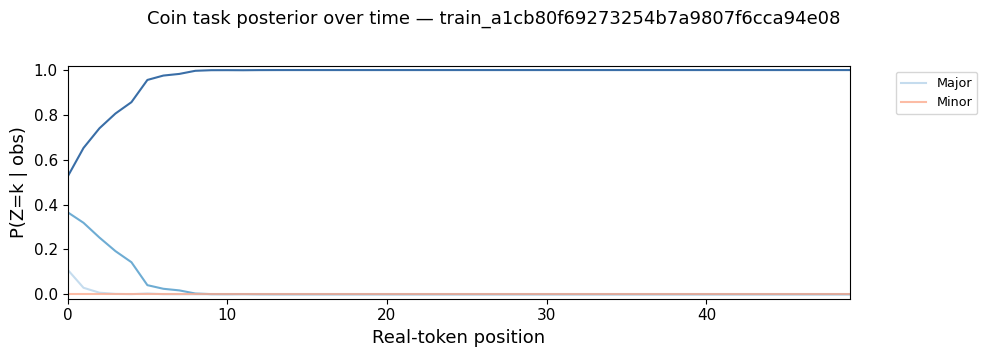

In [2]:
from icl.coin.coin_analysis import plot_coin_task_posterior
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", k=-1)
# Plot task posteriors for 3 random samples
info = plot_coin_task_posterior(
    exp_name,
    n_plots=1,
    max_positions=50,
    major_only=True,
)

# Access the posteriors programmatically if needed
# info['posteriors'] is a list of (seq_len, n_tasks) tensors, one per sample
# info['fig'] and info['axes'] give you the matplotlib objects

## Task-vector $R^2$: long-context stability

### Definition

Given token-conditioned hidden states $\mathbf{h}_{k,a,b}$ (task $k$, token $a$, batch replicate $b$), define cell means $\hat{\boldsymbol{\theta}}_{k,a} = \frac{1}{B}\sum_b \mathbf{h}_{k,a,b}$ and the grand mean $\bar{\mathbf{h}} = \frac{1}{K|V|B}\sum_{k,a,b}\mathbf{h}_{k,a,b}$.

By the **law of total variance**:

$$
\underbrace{\sum_{k,a,b}\|\mathbf{h}_{k,a,b}-\bar{\mathbf{h}}\|^2}_{\mathrm{SS_{total}}}
\;=\;
\underbrace{B\sum_{k,a}\|\hat{\boldsymbol{\theta}}_{k,a}-\bar{\mathbf{h}}\|^2}_{\mathrm{SS_{between}}}
\;+\;
\underbrace{\sum_{k,a,b}\|\mathbf{h}_{k,a,b}-\hat{\boldsymbol{\theta}}_{k,a}\|^2}_{\mathrm{SS_{within}}}
$$

The **task-vector $R^2$** is

$$
R^2 \;=\; 1 - \frac{\mathrm{SS_{within}}}{\mathrm{SS_{total}}}
\;=\; \frac{\mathrm{SS_{between}}}{\mathrm{SS_{total}}}
$$

### Interpretation

$R^2$ measures what fraction of hidden-state variance is explained by knowing (task, token). Under the task-vector model $\mathbf{h}_t \approx \boldsymbol{\mu}_t + \boldsymbol{\theta}_{z, s_t}$, we expect $R^2 \to 1$ as position $t$ grows (long-context stability). Low $R^2$ means the hidden state still carries significant sequence-specific noise beyond (task, token).

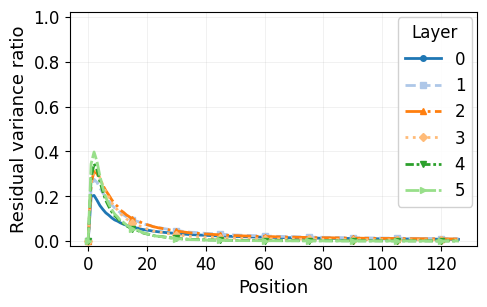

In [3]:
from icl.coin.analysis import plot_task_vector_r2_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1)
results = plot_task_vector_r2_coin(
    exp_name, 
    layers=range(6), 
    batch_size=1024,
    print_summary=False,
    log_x=False,
    extraction_point="post_mlp",
    )

## ANOVA separability: $\boldsymbol{\theta}_{k,a} \stackrel{?}{=} \boldsymbol{\theta}_k + \boldsymbol{\nu}_a$

### Definition

Given cell means $\hat{\boldsymbol{\theta}}_{k,a}$, the two-way ANOVA decomposes them into **task**, **token**, and **interaction** effects:

$$
\hat{\boldsymbol{\theta}}_{k,a} - \hat{\boldsymbol{\theta}}_{\cdot\cdot}
\;=\;
\underbrace{(\hat{\boldsymbol{\theta}}_{k\cdot} - \hat{\boldsymbol{\theta}}_{\cdot\cdot})}_{\boldsymbol{\tau}_k}
\;+\;
\underbrace{(\hat{\boldsymbol{\theta}}_{\cdot a} - \hat{\boldsymbol{\theta}}_{\cdot\cdot})}_{\boldsymbol{\nu}_a}
\;+\;
\underbrace{(\hat{\boldsymbol{\theta}}_{k,a} - \hat{\boldsymbol{\theta}}_{k\cdot} - \hat{\boldsymbol{\theta}}_{\cdot a} + \hat{\boldsymbol{\theta}}_{\cdot\cdot})}_{\mathbf{I}_{k,a}}
$$

where $\hat{\boldsymbol{\theta}}_{k\cdot}$, $\hat{\boldsymbol{\theta}}_{\cdot a}$, $\hat{\boldsymbol{\theta}}_{\cdot\cdot}$ are marginal and grand means. The decomposition is **orthogonal** (balanced design):

$$
\mathrm{SS_{total}} = \mathrm{SS_{task}} + \mathrm{SS_{token}} + \mathrm{SS_{interaction}}
$$

The **interaction proportion** $\eta^2_{\mathrm{interaction}} = \mathrm{SS_{interaction}}/\mathrm{SS_{total}}$ measures the fraction of cell-mean structure due to task–token coupling.

### Interpretation

The **separability $R^2$** $= 1 - \eta^2_{\mathrm{interaction}}$ measures how well the additive model $\boldsymbol{\theta}_{k,a} = \boldsymbol{\theta}_k + \boldsymbol{\nu}_a$ fits. For the coin task (i.i.d. tokens given $z$), separability should hold across all layers. For Markov chains, the transition matrix $p_k(s_t, \cdot)$ inherently couples $k$ and $s_t$, so $\eta^2_{\mathrm{interaction}}$ should be substantial in the final layers.

Note: this metric operates on **cell means only** (noise-free), unlike the task-vector $R^2$ above which includes within-cell variance. The two answer different questions.

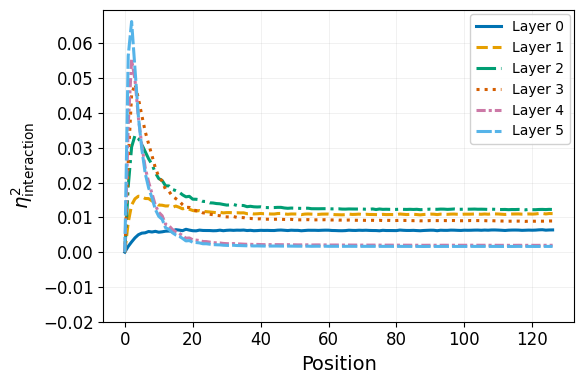

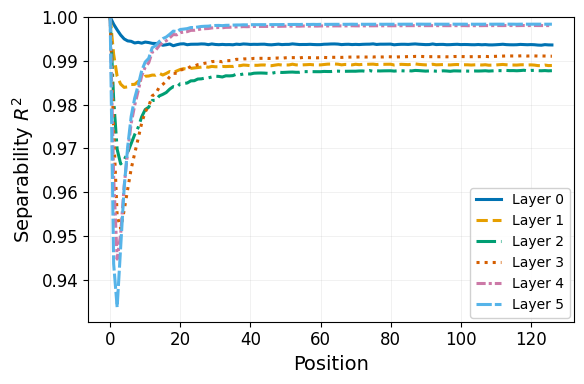

In [3]:
from icl.coin.analysis import plot_anova_separability_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1)
results = plot_anova_separability_coin(
    exp_name, 
    layers=range(6), 
    batch_size=1024,
    log_x=False,
    print_summary=False,
    extraction_point="post_mlp",
    )

In [4]:
anova_results = results["anova_results"]
print("E1 (Coin) — η²_interaction at final position")
print("-" * 50)
for layer in sorted(anova_results.keys()):
    pos_dict = anova_results[layer]
    final_pos = max(pos_dict.keys())
    eta2 = pos_dict[final_pos].eta2_interaction
    print(f"  Layer {layer:>2d}: η² = {eta2:.4f}  (pos={final_pos})")

E1 (Coin) — η²_interaction at final position
--------------------------------------------------
  Layer  0: η² = 0.0064  (pos=126)
  Layer  1: η² = 0.0111  (pos=126)
  Layer  2: η² = 0.0123  (pos=126)
  Layer  3: η² = 0.0090  (pos=126)
  Layer  4: η² = 0.0020  (pos=126)
  Layer  5: η² = 0.0016  (pos=126)


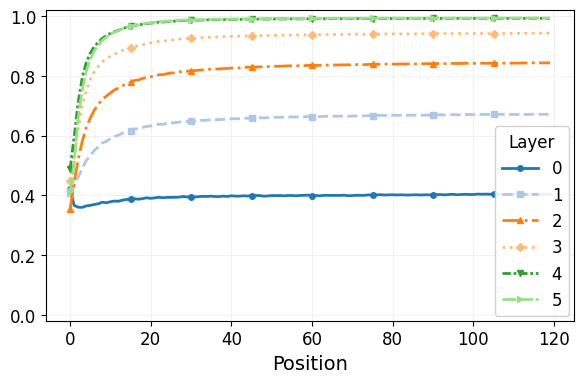

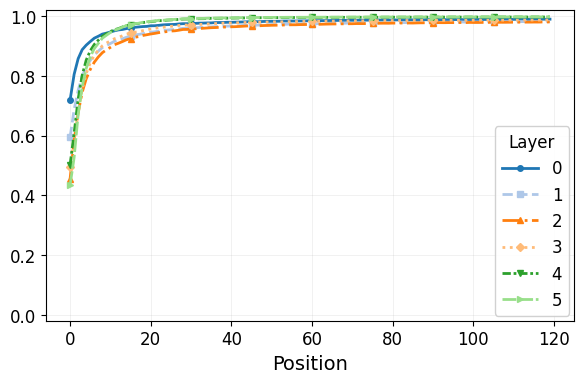

In [5]:
from icl.coin.analysis import plot_averaging_r2_coin
from icl.utils.unified_interface import get_exp_name


exp_name = get_exp_name("coin", k=-1)

# Plot task posteriors for 3 random samples

result = plot_averaging_r2_coin(
    exp_name, layers=range(6),
    estimation_positions=list(range(100, 120)),
    evaluation_positions=range(120),
    fit_token="anova",
    batch_size=256, 
    per_position_mean=True,
    per_position_token_vecs=False,
    log_x=False,
    show_ylabel=True,
    extraction_point="post_mlp",
    )

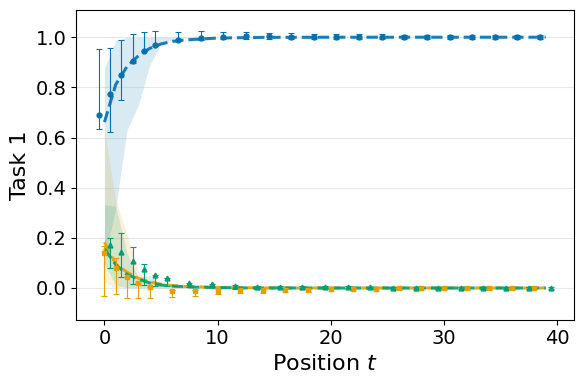

In [6]:
from icl.coin.analysis import traj_averaging_projection_plot_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1)
result = traj_averaging_projection_plot_coin(
    exp_name, 
    layer_index=5,
    task_ids=[0],
    estimation_positions=list(range(30, 40)),
    plot_positions=list(range(40)),
    figsize=(6,4),
    B=1024,
    show_legend=False,
    extraction_point="post_mlp",
    post_layernorm=False,
    beta_errbar="quantile",
    per_position_mean=True,
    project_beta_simplex=False,
    )

## Linear probe: posterior + token $\to$ hidden state

### Model

Fit an OLS regression predicting the hidden state at layer $\ell$ from the
Bayesian posterior and the current token:

$$
\mathbf{h}_\ell(t) \;=\; \boldsymbol{\pi}_t \, W_{\mathrm{task}}
  + \mathbf{e}_{x_t} \, W_{\mathrm{tok}} + \mathbf{b} + \boldsymbol{\varepsilon},
$$

where $\boldsymbol{\pi}_t \in \mathbb{R}^K$ is the posterior vector, $\mathbf{e}_{x_t}$
is the one-hot token indicator, $W_{\mathrm{task}} \in \mathbb{R}^{K \times D}$
and $W_{\mathrm{tok}} \in \mathbb{R}^{V \times D}$ are the fitted weights,
and $\mathbf{b} \in \mathbb{R}^D$ is the bias.

### Why joint fitting

Including both the posterior and the token one-hot in a single regression
ensures that $W_{\mathrm{task}}$ captures variation attributable to the posterior
*after* accounting for the current token, and vice versa.  This avoids
omitted-variable bias that would arise from fitting them separately.

### Diagnostics

The function reports:
- **$R^2$** (total and per-feature-group partial $R^2$).
- **$F$-test** for whether each feature group is significant.
- **Collinearity diagnostics**: condition number, VIF, and pairwise $R^2$
  between the posterior and token feature groups.

In [7]:
from icl.coin.analysis.probes import train_linear_hidden_predictor_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1)
results = train_linear_hidden_predictor_coin(
    exp_name,
    layer=2,
    B=64,
    n_samples=2048,
    positions = range(128),
    sample_mode = "major",
    include_position_bias=False,
)


=== Fit Summary (Coin, layer 2, mode='major') ===
  [posterior col dropped: sum(pi)=1 detected, last column removed to avoid dummy-variable trap]
  [token & position one-hot: last column dropped from each to avoid dummy-variable traps]
Model                            Train R²     Val R²      Val MSE
----------------------------------------------------------------
Joint (post+tok)                   0.9275     0.9274     0.075152
Posterior                          0.7097     0.7109     0.299353
Token                              0.5484     0.5518     0.464095

Partial R²  posterior|token = 0.8381    token|posterior = 0.7490
F-test  posterior: F=547990.4 p=0.00e+00   token: F=89943.5 p=0.00e+00
Condition number: 14.1

  Design matrix collinearity:
    Group         dims        VIF  GVIF^(1/2p)   R² from rest
    -------------------------------------------------------
    posterior        2       1.51       1.1092         0.3394
    token            7       1.13       1.0088         0.11

## Validation $R^2$ of the linear probe across layers

Runs `train_linear_hidden_predictor_coin` at every layer and plots:

- **Total $R^2$**: fraction of variance in $\mathbf{h}_\ell$ explained by
  $[\boldsymbol{\pi}_t,\, \mathbf{e}_{x_t}]$ jointly.
- **Partial $R^2$ (posterior)**: additional variance explained by adding
  the posterior to a token-only model.
- **Partial $R^2$ (token)**: additional variance explained by adding the
  token one-hot to a posterior-only model.

High total $R^2$ at later layers means the hidden state is well-described
by a linear function of the posterior and the current token.  The partial
$R^2$ breakdown reveals which component dominates at each layer.

### Design-matrix collinearity diagnostics

Because the design matrix $X = [\boldsymbol{\pi},\, \mathbf{e}_{x_t}]$ is
constructed from data produced by the *same* model, the posterior features
and the token one-hot features are not independent — knowing
$\boldsymbol{\pi}_t$ tells you something about $x_t$ and vice versa.
To quantify this **collinearity** we report three statistics (computed
once on the training split, since the design matrix is layer-independent):

| Statistic | Definition | Interpretation |
|-----------|------------|----------------|
| **VIF** (Variance Inflation Factor) | For a feature *group* $G$ with $p$ columns, regress $G$ on all other features (plus intercept): $G = X_{\text{rest}}\,W + b + \varepsilon$. Compute the $R^2$ of that regression (call it $R^2_{\text{rest}}$). Then $\text{VIF} = \frac{1}{1 - R^2_{\text{rest}}}$. | VIF $= 1$ means no linear dependence; VIF $\gg 1$ means the group is largely redundant given the other features. Values below $\approx 5$ are generally considered safe. |
| **GVIF$^{1/(2p)}$** (Generalised VIF, adjusted) | $\text{GVIF}^{1/(2p)} = \text{VIF}^{1/(2p)}$ where $p$ is the number of columns in the group. | Adjusts for group dimension so that groups with different numbers of columns are comparable. Values near 1 mean low collinearity. |
| **$R^2$ from rest** | The $R^2_{\text{rest}}$ used inside the VIF formula. It equals the fraction of the group's total variance that the *other* group can explain linearly. | Directly tells you the overlap. $R^2_{\text{rest}} \approx 0$ means the two groups are nearly orthogonal; $R^2_{\text{rest}} \approx 1$ means one group is almost a linear function of the other. |

#### How to read the table

```
Group         dims        VIF  GVIF^(1/2p)   R² from rest
-------------------------------------------------------
posterior        3       1.27       1.0410         0.2144
token            6       1.10       1.0080         0.0908
```

- **posterior** group has $p = 3$ columns (one per major task, since the
  posterior $\boldsymbol{\pi}_t \in \mathbb{R}^3$). Its
  $R^2_{\text{rest}} = 0.21$ means the token one-hot can linearly explain
  about 21% of the posterior's variance. VIF $= 1/(1 - 0.21) \approx 1.27$.
  GVIF$^{1/(2 \cdot 3)} = 1.27^{1/6} \approx 1.041$.

- **token** group has $p = 6$ columns (one-hot with vocab size 6). Its
  $R^2_{\text{rest}} = 0.09$ — the posterior can only explain about 9% of
  the token variance. VIF $\approx 1.10$ and GVIF$^{1/12} \approx 1.008$.

Both VIFs are very close to 1, confirming that the posterior and token
feature groups contribute largely independent information to the linear
probe. This justifies interpreting the partial $R^2$ values as
meaningful, non-redundant contributions.

2026-03-27 09:12:28 - icl.coin.analysis.probes - INFO - [sweep] collecting data for 6 layers (ep='post_attn') ...
2026-03-27 09:12:30 - icl.coin.analysis.probes - INFO - [sweep] fitting layer 0 (ep='post_attn') ...
2026-03-27 09:12:44 - icl.coin.analysis.probes - INFO - [sweep] fitting layer 1 (ep='post_attn') ...
2026-03-27 09:12:55 - icl.coin.analysis.probes - INFO - [sweep] fitting layer 2 (ep='post_attn') ...
2026-03-27 09:13:08 - icl.coin.analysis.probes - INFO - [sweep] fitting layer 3 (ep='post_attn') ...
2026-03-27 09:13:21 - icl.coin.analysis.probes - INFO - [sweep] fitting layer 4 (ep='post_attn') ...
2026-03-27 09:13:33 - icl.coin.analysis.probes - INFO - [sweep] fitting layer 5 (ep='post_attn') ...

  Design Matrix Collinearity Summary (layer-independent)
  Condition number: 2.94e+01
  Features: posterior=2  token=7  (total=32)

  Group         dims        VIF  GVIF^(1/2p)   R² from rest
  -------------------------------------------------------
  posterior        2       1.

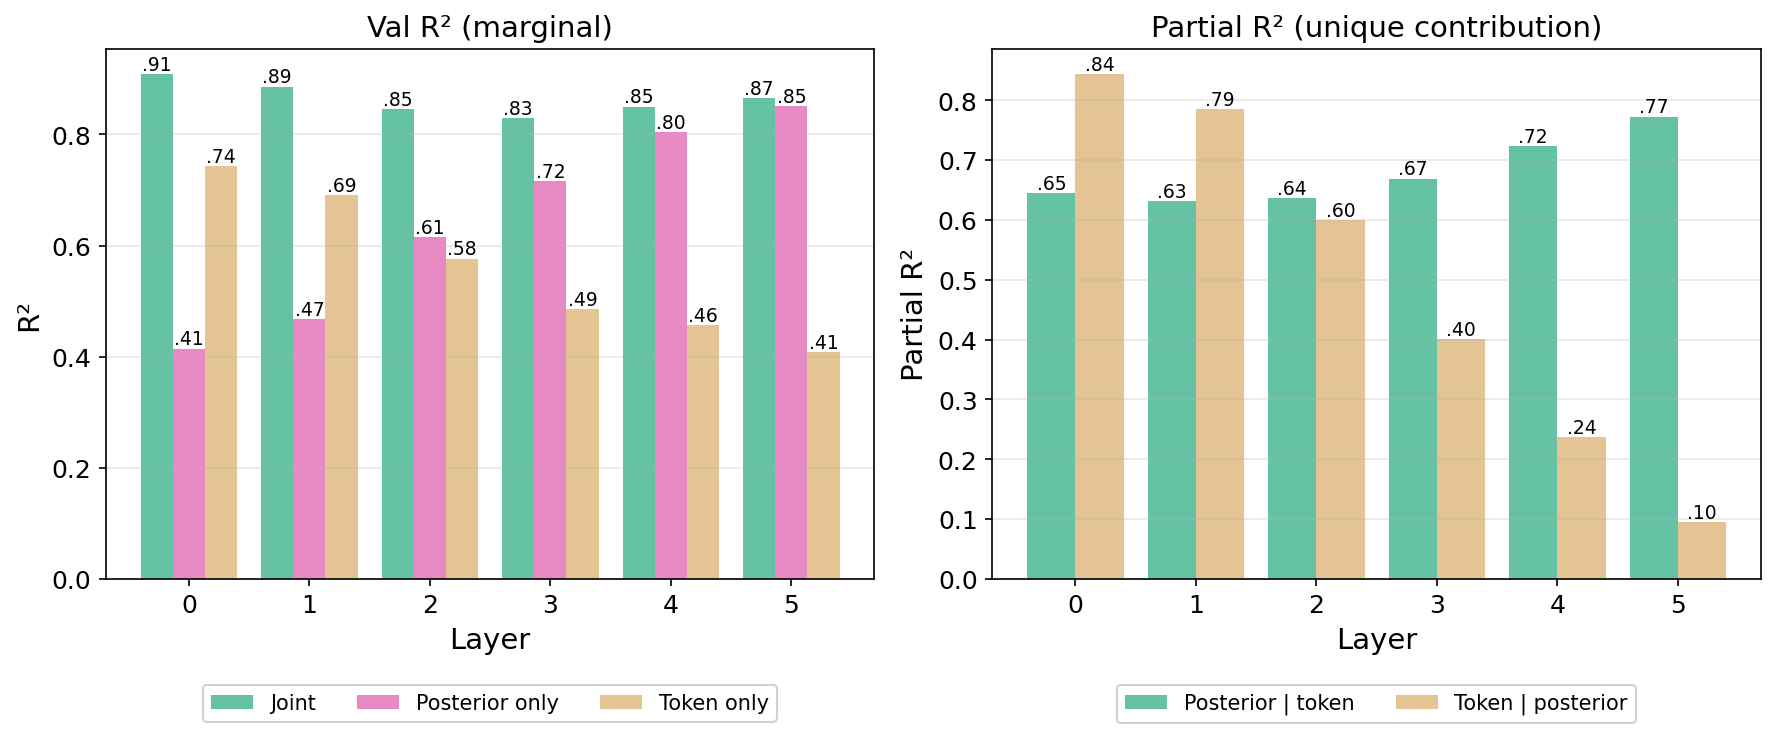

In [2]:
from icl.coin.analysis.probes import plot_val_r2_across_layers_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1)
fig, all_results = plot_val_r2_across_layers_coin(
    exp_name=exp_name,
    n_samples=2**13,
    positions=range(1, 25),
    sample_mode="major",
)

## ID vs OOD training loss curves

Plots the **in-distribution (ID) loss** and **out-of-distribution (OOD)
loss** logged during training, side by side, for multiple task-diversity
settings (different $k$ values).

- **ID loss**: cross-entropy on data drawn from the training mixture
  (major + minor tasks).
- **OOD loss**: cross-entropy on data from fresh Dirichlet draws
  (tasks the model has never seen).

Comparing curves across $k$ reveals how task diversity during training
affects generalisation: higher $k$ (more minor tasks) typically leads
to lower OOD loss at convergence.

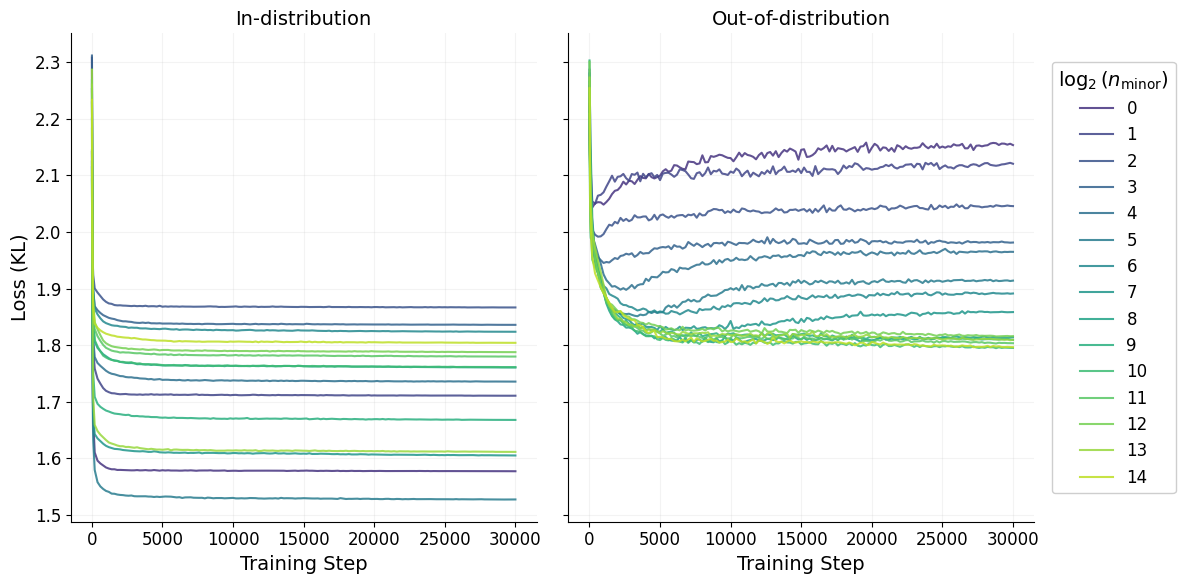

In [2]:
from icl.coin.coin_analysis import plot_id_ood_loss_coin

out = plot_id_ood_loss_coin(
    k_list=range(15),
    logx=False,
    figsize=(12, 6),
)

## KL divergence: model vs Bayesian baselines

### Goal

Measure how close the transformer's next-token distribution is to two
Bayesian reference predictors, as a function of sequence position.

### Baselines

1. **Exact known-pool Bayes** (`KnownPoolBayesCoins`): maintains the
   posterior over all tasks in the pool (major + minor) and predicts
$$
p_{\mathrm{exact}}(x_{t+1} \mid x_{1:t})
  = \sum_k P(Z{=}k \mid x_{1:t})\; p_k(x_{t+1}).
$$

2. **3-known + Dirichlet-new** (`ThreeKnownPlusNewDirichletCoinBayes`):
   maintains a posterior over the 3 major tasks plus one "catch-all" bucket
   with a Dirichlet($\alpha$) prior for unseen tasks.

### Metric

At each position $t$ and sample $n$, compute:

$$
D_{\mathrm{KL}}\bigl(p_{\mathrm{model}}(\cdot \mid x_{1:t})
  \;\|\; p_{\mathrm{baseline}}(\cdot \mid x_{1:t})\bigr).
$$

Plot mean $\pm$ std over samples.

### Two variants

- `plot_kl_model_vs_two_bayes_coin` — single experiment, multiple
  modes (train / major / minor / ood) as subplots.
- `plot_kl_model_vs_two_bayes_coin_across_k` — sweeps across multiple
  $k$ values (task-diversity settings) for one mode, coloring each $k$
  as a separate curve.

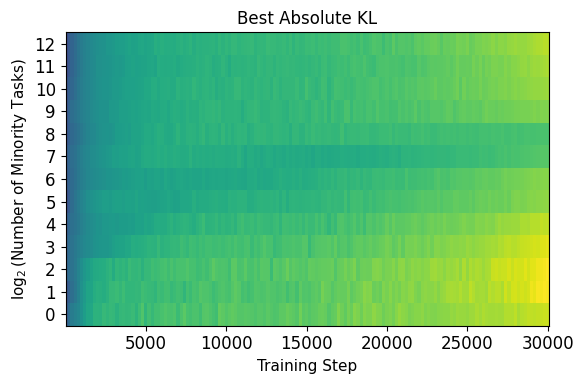

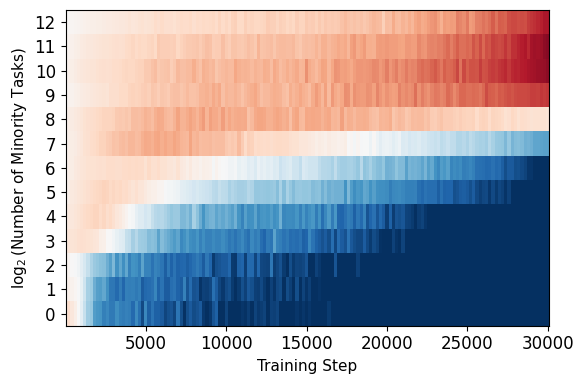

<Figure size 640x480 with 0 Axes>

In [1]:
from icl.coin.coin import plot_kl_model_vs_two_bayes_coin_transition_across_k

out = plot_kl_model_vs_two_bayes_coin_transition_across_k(
    k_values=range(13),
    mode="train",
    num_samples=1024,
    show_colorbar=False,
    show=True,
    figsize=(6,4),
    
)

2026-03-23 17:36:25 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_9ebf5b688be3802d1f21acec8e7167fa: skipping 81 requested steps not found on disk (e.g. [0, 10200, 10400]...). Pass steps that match available checkpoints to suppress this.
2026-03-23 17:36:31 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_46d48df2337e8deec53b2e894692aafd: skipping 81 requested steps not found on disk (e.g. [0, 10200, 10400]...). Pass steps that match available checkpoints to suppress this.
2026-03-23 17:36:36 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_0da53e6a30b7d115d91aa30cb4673fd1: skipping 81 requested steps not found on disk (e.g. [0, 10200, 10400]...). Pass steps that match available checkpoints to suppress this.
2026-03-23 17:37:44 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_452f46eb902b26479ac63837807f1d5d: skipping 81 requested steps not found on disk (e.g. [0, 10200, 10400]...)

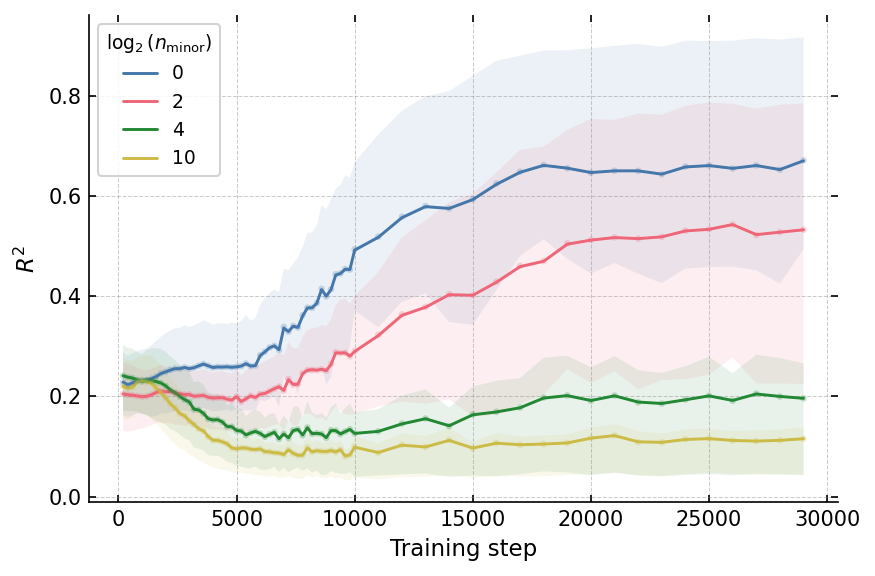

In [ ]:
from icl.utils.ood_major_projection_r2 import plot_maj_r2_ood_across_steps_coin

# Default: position blocks (0,10), (10,20), (20,-1) → one curve per (k, block)
out = plot_maj_r2_ood_across_steps_coin(
    k_list=[-1, 10],
    steps= list(range(0, 30_000, 200)),
    layer=4,
    n_gpus=2,
    ema_alpha=0.95,
    logx=False,
    n_ood=64,
    B=32,
    show_title=False,
    position_blocks=((0,-1),),
    figsize=(6,4),
    extraction_point="post_mlp",
    band_alpha=0.1,
)
# Returns dict with fig, ax, results, title, subtitle

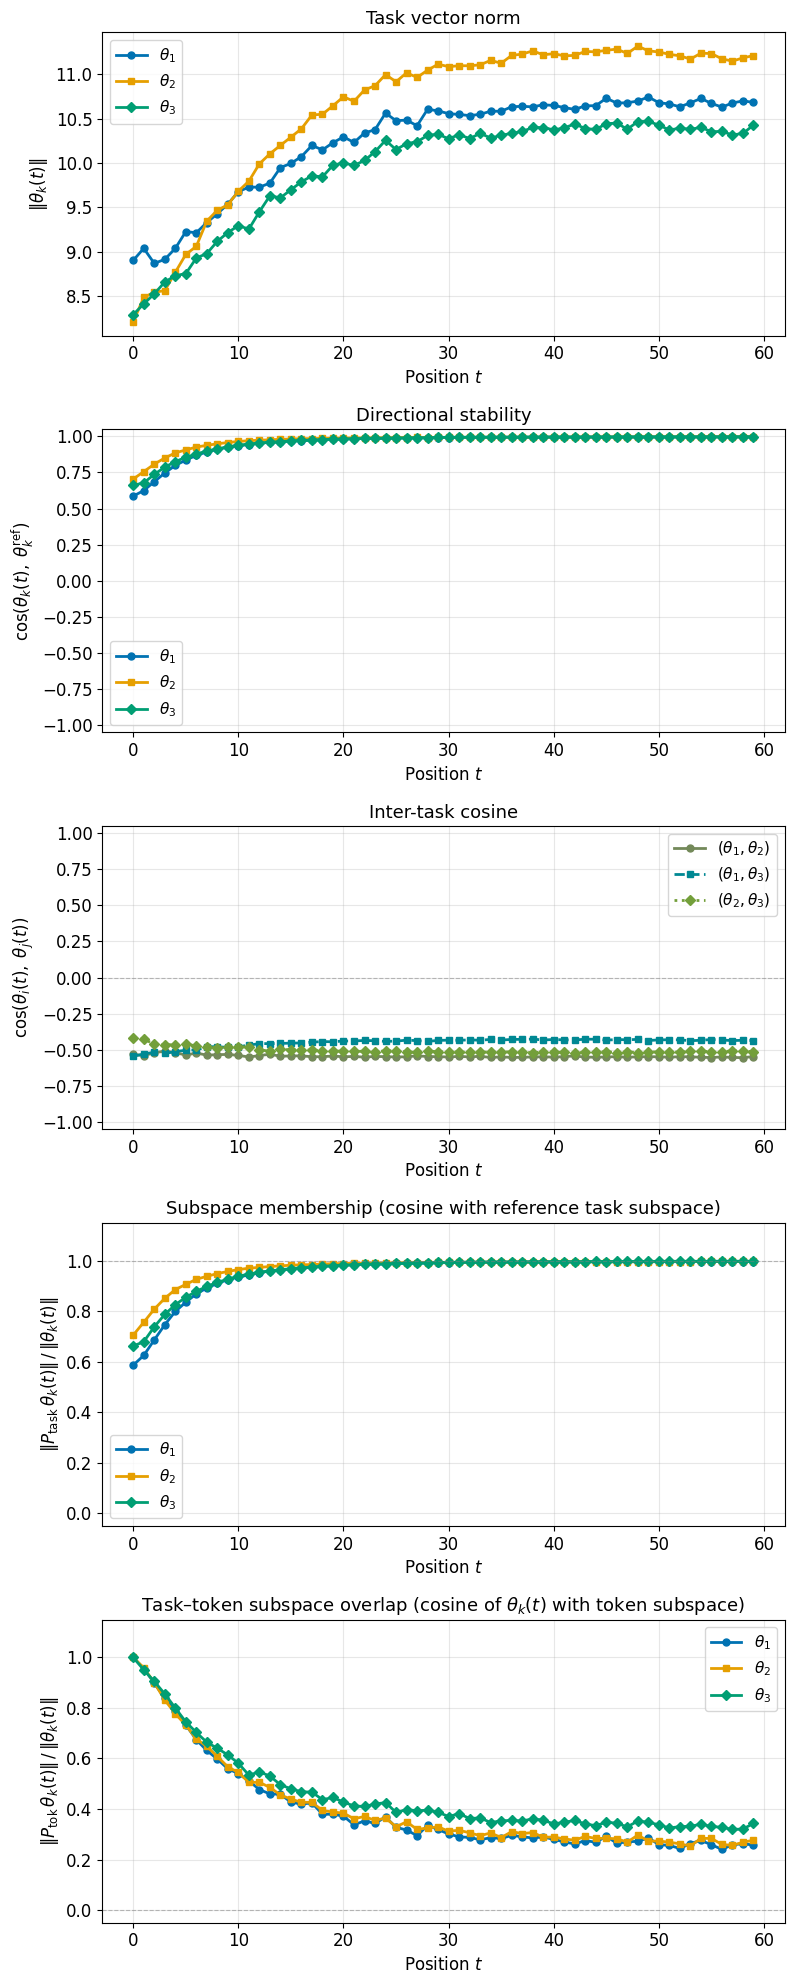

In [ ]:
from icl.utils.unified_plot import plot_task_vector_geometry
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", 10)
result = plot_task_vector_geometry("coin", exp_name, layer_index=3, B=1024, marker_every=1, plot_positions=range(60), balanced=False,)

## Averaging-based task-vector injection

### Setup

Task vectors are estimated by **averaging** hidden states across samples,
without fitting any probe on the Bayesian posterior:

1. **Task-vector estimation.** For each major task $k$ and a set of
   late "estimation positions", collect hidden states
   $\mathbf{h}_\ell^{(k)}(t)$ and average over both positions and
   samples to obtain the task mean $\bar{\mathbf{h}}_k$.  The centred
   task vector is $\widetilde{\mathbf{v}}_k = \bar{\mathbf{h}}_k -
   \bar{\mathbf{h}}$, where $\bar{\mathbf{h}}$ is the grand mean.
   These satisfy $\sum_k \widetilde{\mathbf{v}}_k = \mathbf{0}$.

2. **$\alpha$ sampling.** Draw
   $\alpha \sim \mathrm{Dirichlet}(1,\dots,1)$ independently per
   sample — one $\alpha$ per sample, constant across positions.

3. **Injection.** At the target layer and each evaluation position $t$,
   replace the task-subspace component of the hidden state:
   $$\mathbf{h}'_t \;=\; \mathbf{h}_t \;-\; P_{\mathrm{task}}\,(\mathbf{h}_t - \boldsymbol{\mu}_t)
     \;+\; \sum_k \alpha_k\,\widetilde{\mathbf{v}}_k,$$
   where $P_{\mathrm{task}}$ projects onto the span of
   $\{\widetilde{\mathbf{v}}_k\}$ and $\boldsymbol{\mu}_t$ is the
   per-position grand mean (or the global grand mean when
   `per_position_mean=False`).

4. **Target output.** The $\alpha$-weighted mixture
   $q = \sum_k \alpha_k\, p_k$, where $p_k$ is the categorical
   distribution of task $k$.

5. **Metrics.**
   - $\mathrm{KL}(\text{baseline} \,\|\, q_\alpha)$ — unmodified model vs. mixture.
   - $\mathrm{KL}(\text{injected} \,\|\, q_\alpha)$ — injected model vs. mixture.
   - $\mathrm{KL}(\text{mode} \,\|\, q_\alpha)$ — MAP-task prediction $p_{k^\star}$ vs. mixture.

### Interpretation

- $\alpha$ is **controlled**, not inferred — no posterior convergence issues.
- A large drop from baseline KL to injected KL, with injected KL well
  below the mode KL, is **direct causal evidence** that the hidden
  representation linearly encodes task-mixture weights via the averaging-based
  task vectors.
- Results are shown on ternary simplex plots (one per condition), coloured
  by KL divergence at each sampled $\alpha$.

2026-03-28 16:17:26 - icl.coin.analysis.interventions.inject_posterior - INFO - [avg inj coin per-pos] K=3, direct subtraction with per-position task vectors


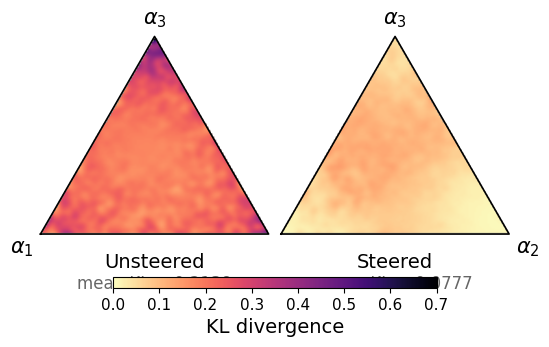

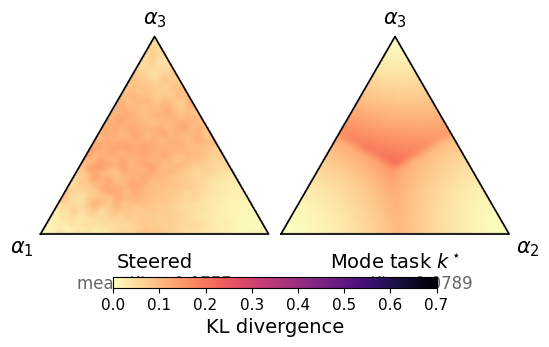


Averaging Injection  (coin, layer 3)
  rank=None  K=3  dirichlet_alpha=1.0
  Mean KL(baseline || q_α) = 0.2139
  Mean KL(injected || q_α) = 0.0777
  Mean KL(mode || q_α)     = 0.0789



In [4]:
from icl.coin.analysis.interventions import intervene_averaging_injection_coin
from icl.utils.unified_interface import get_exp_name

MAJOR_MEANS = [1.5, 2.5, 3.5]
VOCAB_SIZE = 6
POOL_TYPE = "partition"

exp_name = get_exp_name("coin", -1, vocab_size=16)
result = intervene_averaging_injection_coin(
    exp_name=exp_name, 
    layer=3, 
    verbose=True,
    estimation_positions=range(25, 40),
    eval_positions=range(25, 40),
    estimation_B=1024,
    B=10_000,
    per_position_mean=True,
    use_per_position_vecs=True,
    extraction_point="post_mlp",
    post_layernorm=False,
    color_vmin=0, 
    color_vmax=0.7,
    )

## 2-D trajectory projection via posterior-derived task vectors

### Goal

Visualize how the transformer's hidden representation $\mathbf{h}_\ell(t) \in \mathbb{R}^D$
at layer $\ell$ and position $t$ evolves over the sequence, projected onto a
2-D plane that captures the task-identity directions.

### Step 1 — Fit a linear probe (posterior $\to$ hidden)

Using **major-task** data at late positions (by default $t \in [100, T)$),
fit an OLS model that predicts the hidden state from the Bayesian posterior
and a one-hot token indicator:

$$
\mathbf{h}_\ell(t) \;\approx\; \boldsymbol{\pi}_t \, W + \mathbf{e}_{x_t} \, W_{\mathrm{tok}} + \mathbf{b},
$$

where $\boldsymbol{\pi}_t = P(Z{=}k \mid x_{1:t})$ is the $K$-dimensional
posterior vector (here $K = 3$ major tasks), $W \in \mathbb{R}^{K \times D}$
are the **task directions**, and $\mathbf{b} \in \mathbb{R}^D$ is the bias.
We include the token one-hot $\mathbf{e}_{x_t}$ as a covariate so that the
fitted $W$ captures only the task-posterior component of the hidden state,
not variation explained by the current token.

This is done by `train_linear_hidden_predictor_coin`.

### Step 2 — Define centred task vectors

The rows of $W$ point in the direction that each task's posterior
pushes the hidden state.  Centre them to remove the shared component:

$$
\widetilde{W}_k = W_k - \bar{W}, \qquad \bar{W} = \frac{1}{K}\sum_{k=1}^{K} W_k.
$$

These $\widetilde{W}_k$ are the **final task vectors** that define the projection plane.
They satisfy $\sum_k \widetilde{W}_k = \mathbf{0}$, which means the origin of the
projection corresponds to the uniform-posterior state.

### Step 3 — Extract hidden trajectories

For each group (major / OOD / minor), generate $B$ sequences, run the
model, and collect $\mathbf{h}_\ell(t)$ at every position $t$.

**Batch-mean mode** (`use_mean=True`): average over the $B$ samples for each
task, giving one trajectory $\bar{\mathbf{h}}_\ell^{(k)}(t)$ per task.

**Individual mode** (`use_mean=False`): keep $b$ individual trajectories per
task to visualize stochastic variation.

Compute the **centred trajectory** by subtracting the grand mean of the
$K_{\mathrm{major}}=3$ major-task averages at each position:

$$
\mathbf{v}^{(k)}(t) = \bar{\mathbf{h}}_\ell^{(k)}(t)
  - \frac{1}{K_{\mathrm{major}}} \sum_{j=1}^{K_{\mathrm{major}}}
    \bar{\mathbf{h}}_\ell^{(j)}(t).
$$

### Step 4 — Project onto the task-vector plane ($\lambda$ coefficients)

Express each centred trajectory as a linear combination of the
centred task vectors via OLS:

$$
\mathbf{v}^{(k)}(t) \approx \sum_{j=1}^{K} \lambda_j^{(k)}(t)\, \widetilde{W}_j.
$$

Since $\sum_j \widetilde{W}_j = 0$, the system is rank-deficient; drop the
last column, solve for $\lambda_1, \ldots, \lambda_{K-1}$, and set
$\lambda_K = 1 - \sum_{j<K} \lambda_j$ so that **$\sum_j \lambda_j = 1$**.

The $\lambda$ coefficients have a geometric interpretation: they are
barycentric coordinates in the simplex spanned by the task vectors.
For major tasks at late positions, $\boldsymbol{\lambda}(t) \to \mathbf{e}_k$
(the $k$-th corner).  OOD tasks land at interior points reflecting how the
network "decomposes" a novel distribution into the known major tasks.

The function also computes $R^2(t)$ — the fraction of variance in $\mathbf{v}^{(k)}(t)$
explained by the projection.  High $R^2$ means the hidden state lives close
to the task-vector subspace.

### Step 5 — Rescale and plot

The probe-derived task vectors $\widetilde{W}_k$ may have a different norm
scale than the actual hidden-state differences.  The function rescales
$\widetilde{W}_k$ so that $\|\widetilde{W}\|_F$ matches the norm of the
actual major endpoints $\mathbf{v}^{(k)}(T)$, ensuring the 2-D plot shows
correct relative distances.

The plot uses the first two $\lambda$ coordinates as $(x, y)$ axes:
- **Major tasks** converge to distinct corners of the simplex.
- **OOD tasks** trace paths through the interior, revealing which major
  tasks they resemble and how the network's "belief" evolves.
- Marker size encodes $R^2(t)$: larger = better fit.
- Time indices are selected via farthest-point sampling for clarity.

### Usage

```python
from icl.coin.coin_analysis import traj_posterior_projection_plot_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1,
    vocab_size=VOCAB_SIZE,
    major_pool_type="tilted",
    major_means=MAJOR_MEANS,
)

result = traj_posterior_projection_plot_coin(
    exp_name=exp_name,
    layer_index=4,      # which transformer layer to probe
    n_ood=256,           # number of OOD (Dirichlet) tasks
    n_minor=0,           # number of minor tasks (0 = none)
    annotate=False,      # True to label time indices on plot
    B=64,                # batch size per task for averaging
    use_mean=True,       # True = batch-mean trajectories
    step=None,           # checkpoint step (None = latest)
)
```

**Key returned fields:**
- `result['lambdas']` — $\lambda$ coefficients, shape $(K, T, K_{\mathrm{major}})$
- `result['r2_scores']` — $R^2$ per trajectory per time step
- `result['final_task_vecs']` — the centred task vectors $\widetilde{W}_k$
- `result['W']`, `result['b']` — raw probe weights and bias
- `result['fig']`, `result['ax']` — matplotlib figure and axes

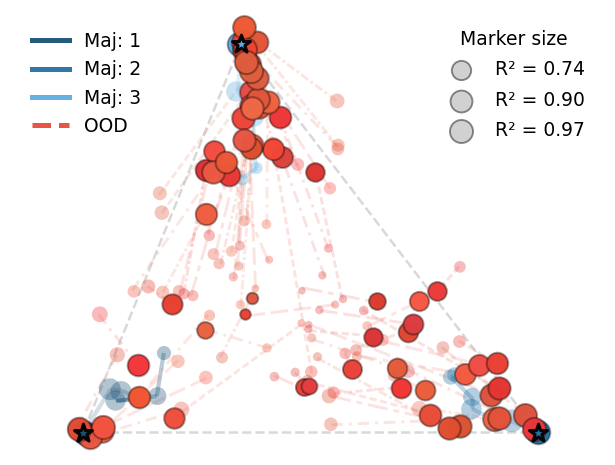

In [5]:
from icl.coin.coin_analysis import traj_posterior_projection_plot_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1)
result = traj_posterior_projection_plot_coin(
    exp_name=exp_name,
    layer_index=3,
    n_ood=64,
    n_minor=0,
    annotate=False,
    extraction_point="post_mlp",
    figsize=(4,3)
)

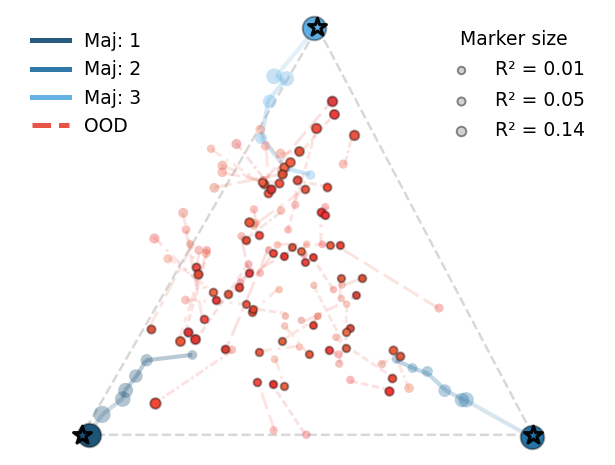

In [6]:
exp_name = get_exp_name("coin", 10)
result = traj_posterior_projection_plot_coin(
    exp_name=exp_name,
    layer_index=3,
    n_ood=64,
    n_minor=0,
    annotate=False,
    extraction_point="post_mlp",
    figsize=(4,3)
)

## Optimal orthogonal-complement intervention

### Motivation

From the linear probe we obtain a **task subspace** spanned by the rows of
$W$ (the directions along which the posterior $\boldsymbol{\pi}_t$ modulates
the hidden state).  The question is: *does the orthogonal complement of this
subspace also carry information that the model uses for prediction?*

If we can find a low-rank subspace in the orthogonal complement whose removal
causally degrades next-token prediction on OOD (or minor) data — but has
little effect on major-task data — then the model has learned an additional
representation beyond the task-identity signal, one that matters specifically
for generalisation.

### Method (per layer)

**Step 1 — Identify the task subspace.**
Fit the linear probe $\mathbf{h} \approx \boldsymbol{\pi} W + \mathbf{e}_{x_t} W_{\mathrm{tok}} + b$
on major-task data (same probe as in the trajectory projection).  Compute the
SVD of $W$ to get an orthonormal basis $U_{\mathrm{task}} \in \mathbb{R}^{D \times r}$
for the task subspace (rank $r \leq K$).

**Step 2 — Build the orthogonal complement.**
Let $P_{\mathrm{task}} = U_{\mathrm{task}} U_{\mathrm{task}}^\top$.  The
projector onto the complement is $P_\perp = I - P_{\mathrm{task}}$.  Extract
an orthonormal basis $U_\perp \in \mathbb{R}^{D \times (D-r)}$ for the
column space of $P_\perp$.

**Step 3 — Find the most important directions via gradient ascent.**
Parameterise a rank-$d$ subspace within the complement as
$V = U_\perp \, \Theta$, where $\Theta \in \mathbb{R}^{(D-r) \times d}$.
The causal intervention replaces the hidden state with

$$
\mathbf{h}' = \mathbf{h} - s \cdot V V^\top \mathbf{h},
$$

i.e. it removes the projection of $\mathbf{h}$ onto $V$ (scaled by $s$).
We run gradient **ascent** on the cross-entropy loss of the intervened model
on OOD/minor data: this finds the subspace whose removal **maximally
degrades** OOD prediction.  After each gradient step, $V$ is
re-orthonormalised via QR and stays within $\operatorname{col}(U_\perp)$.

**Step 4 — Evaluate the intervention causally.**
With the optimised $V^*$, run the full forward pass with the hook
$\mathbf{h} \mapsto \mathbf{h} - s \cdot V^* {V^*}^\top \mathbf{h}$
at the target layer and measure:

- **$\Delta$ loss (major)**: should be small if the removed directions are
  truly orthogonal to the task-identity signal.
- **$\Delta$ loss (OOD / minor)**: should be large if the complement encodes
  useful generalisation information.

**Step 5 — Diagnostic: is the found direction just a unigram statistic?**
Project the hidden states onto $V^*$ and check (via linear and MLP probes)
whether the projection $V^{*\top} \mathbf{h}$ can be predicted from the
cumulative token frequency (CLR-transformed unigram) $\mathbf{u}_t$.  If
$R^2(\mathbf{u}_t \to V^{*\top}\mathbf{h})$ is high, the "orthogonal
complement information" is largely a repackaging of the running token counts.
Additionally, the unigram-explained subspace (the part of $V^*$ that is
linearly predictable from $\mathbf{u}_t$) is tested causally to quantify how
much of the intervention effect it accounts for.

### Outputs (four figures)

1. **$\Delta$ loss bar chart** — the causal effect (major / OOD / minor) at
   each layer, with horizontal lines showing the information gain
   $\ell(t{=}0) - \bar\ell(t)$ as an upper-bound reference.
2. **Validation loss history** — the intervened loss during the gradient
   ascent optimisation (should increase and plateau).
3. **$R^2$ plot** — linear and MLP $R^2$ between unigram features and the
   $V^*$ projection (OOD/minor data), compared with random orthogonal
   baselines.
4. **Explained bar plot** — causal effect of the full $V^*$ vs its
   unigram-explained sub-directions, showing how much of the effect can be
   attributed to token-frequency information.

### Usage

```python
from icl.coin.coin_analysis import plot_optimal_orth_direction_across_layers_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", 12)

fig_delta, fig_loss, fig_r2, fig_explained, all_results = \
    plot_optimal_orth_direction_across_layers_coin(
        exp_name=exp_name,
        layers=range(6),         # which transformer layers to sweep
        n_directions=8,          # rank of the subspace to find (d)
        n_opt_steps=300,         # max gradient-ascent steps
        opt_lr=0.01,             # learning rate for optimisation
        opt_B=32,                # batch size per optimisation step
        patience=100,            # early stopping patience
        grad_clip_norm=0.5,      # gradient clipping norm
        n_samples_eval=2**11,    # samples for causal evaluation
        n_samples_probe=2**10,   # samples for R² diagnostics
        n_ood=128,               # number of OOD tasks
        scale=1.0,               # intervention scale s
        opt_target="minor",      # "ood" or "minor" — which data to
                                 # optimise the direction on
    )
```

**Key parameters:**
- `n_directions` — rank $d$ of the subspace to find; higher = more
  expressive but slower.
- `scale` — intervention strength $s$; 1.0 = full removal.
- `opt_target` — `"ood"` maximises OOD loss degradation; `"minor"`
  maximises minor-task loss degradation.

**Key returned fields** (in `all_results[layer]`):
- `delta_loss_major`, `delta_loss_ood`, `delta_loss_minor` — causal $\Delta$ losses.
- `uni_to_proj_r2_tgt` — $R^2$ from unigram to $V^*$ projection.
- `uni_explained` — per-feature (CLR, Dirichlet-pred) explained rank, $R^2$,
  and causal $\Delta$ of the explained sub-directions.

2026-03-25 14:53:21 - icl.coin.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 1: Collecting token-conditioned hiddens (ANOVA) ...
2026-03-25 14:53:24 - icl.coin.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 2: Loading model & caching eval data ...
2026-03-25 14:53:24 - icl.coin.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 3: Collecting hiddens + unigram ...
2026-03-25 14:53:24 - icl.coin.analysis.interventions.optimal_orth - INFO - [opt-dir] Layer 0 ...
2026-03-25 14:53:40 - icl.coin.analysis.interventions.optimal_orth - INFO -   layer 0: d_maj=0.0340, d_ood=0.3753, d_minor=0.3511, R²(u→V)=0.369
2026-03-25 14:53:40 - icl.coin.analysis.interventions.optimal_orth - INFO - [opt-dir] Layer 1 ...
2026-03-25 14:53:55 - icl.coin.analysis.interventions.optimal_orth - INFO -   layer 1: d_maj=0.0265, d_ood=0.3298, d_minor=0.3041, R²(u→V)=0.608
2026-03-25 14:53:55 - icl.coin.analysis.interventions.optimal_orth - INFO - [opt-dir] Layer 2 ...
2026-03-25 

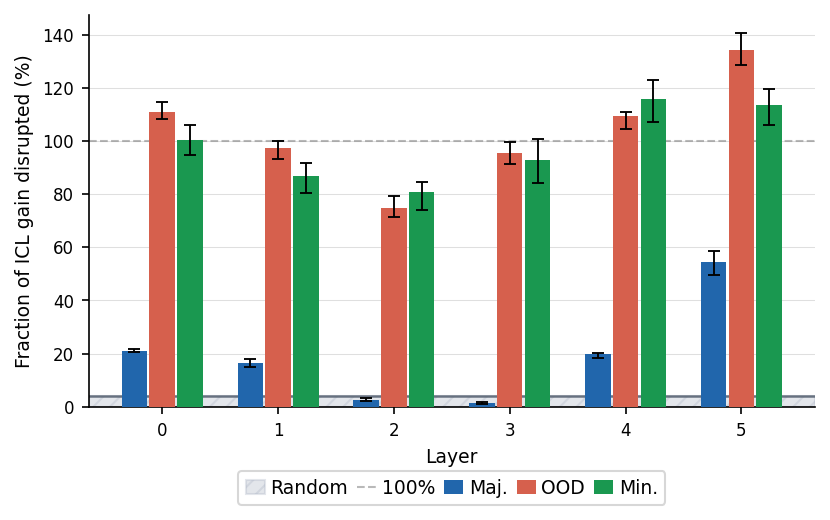


  V_opt Intervention — Δ𝓛/g (% of ICL gain)  [CE nats]
  ───────────────────────────────────────────────────────────────────────
  Layer    Maj.%     OOD%    Min.%   Rand.%  |    Maj.Δ    OOD Δ    Min.Δ
  ───────────────────────────────────────────────────────────────────────
      0     21.0%    110.9%    100.3%      2.8%  |   0.0340   0.3753   0.3511
      1     16.3%     97.4%     86.8%      1.5%  |   0.0265   0.3298   0.3041
      2      2.5%     74.9%     80.8%      2.6%  |   0.0041   0.2536   0.2831
      3      1.4%     95.6%     92.9%      2.9%  |   0.0023   0.3236   0.3252
      4     19.8%    109.5%    115.9%      3.5%  |   0.0321   0.3708   0.4060
      5     54.4%    134.1%    113.4%      3.6%  |   0.0883   0.4541   0.3972
  ───────────────────────────────────────────────────────────────────────
   Gain                                          |   0.1622   0.3386   0.3502

  ─────────────────────────────────────────────────────────
  Layer-averaged (mean ± std across 6 lay

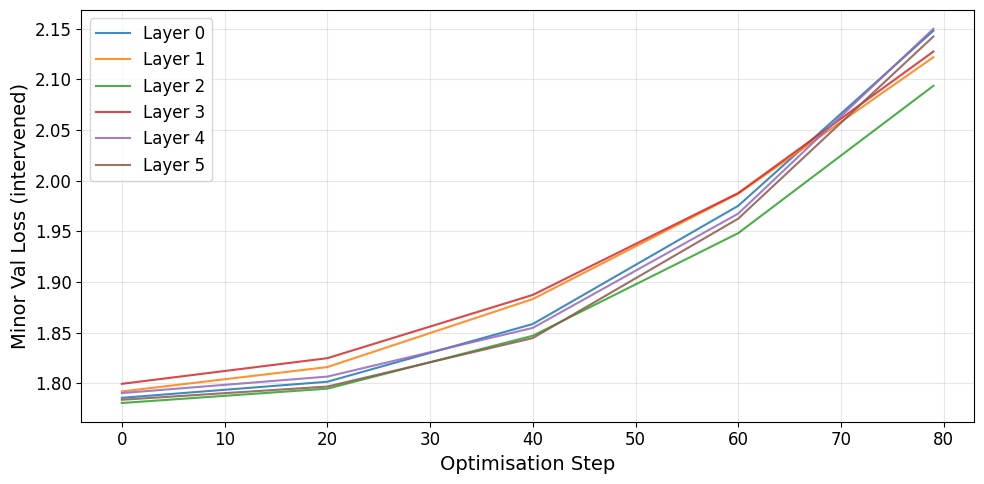

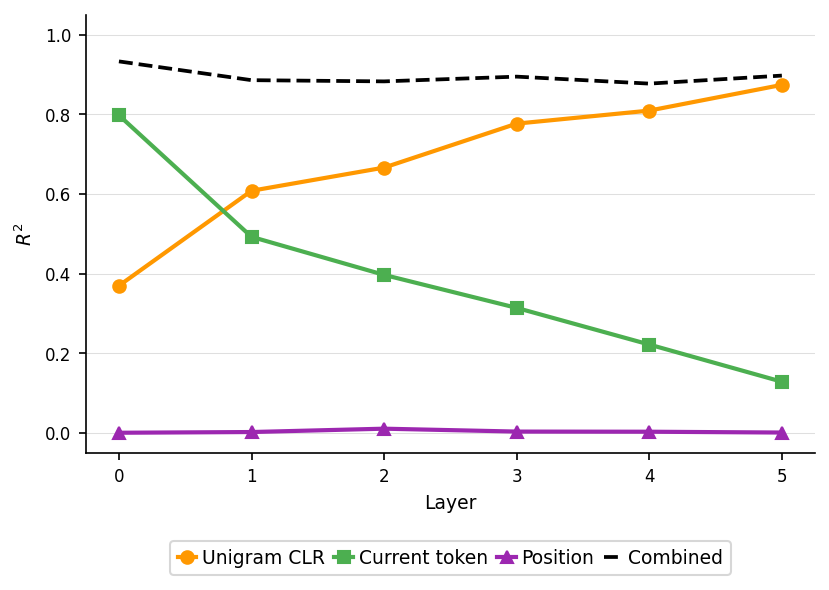

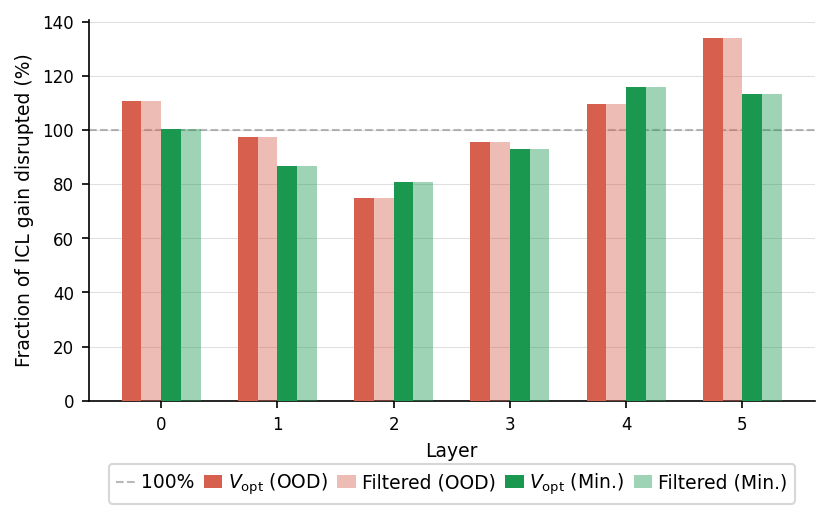


  V_opt & Prediction — Δ𝓛/g (% of ICL gain)  (feat: enriched)
  ───────────────────────────────────────────────────
  Layer  Vopt OOD%  Pred OOD%  Vopt Min.%  Pred Min.%
  ───────────────────────────────────────────────────
      0      110.9%      110.9%      100.3%      100.3%
      1       97.4%       97.4%       86.8%       86.8%
      2       74.9%       74.9%       80.8%       80.8%
      3       95.6%       95.6%       92.9%       92.9%
      4      109.5%      109.5%      115.9%      115.9%
      5      134.1%      134.1%      113.4%      113.4%
  ───────────────────────────────────────────────────



In [1]:
from icl.coin.coin_analysis import plot_optimal_orth_direction_across_layers_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", 10)

all_results = plot_optimal_orth_direction_across_layers_coin(
    exp_name=exp_name,
    layers=range(6),
    n_directions=6,
    n_opt_steps=80,
    opt_lr=0.01,
    opt_B=256,
    patience=50,
    grad_clip_norm=1.0,
    n_samples_eval=2**10,
    n_samples_probe=2**10,
    n_ood=2*10,
    scale=2.5,
    opt_target="minor",
    extraction_point="post_mlp",
    probe_method="averaging",
    figsize=(6,4),
)

## Causal removal of the task subspace

### Idea

If the task subspace (spanned by rows of $W$ from the linear probe) captures
the model's representation of *which task is being performed*, then removing
it should destroy the model's ability to leverage task identity for
next-token prediction.

### Intervention

At layer $\ell$, the hook replaces the hidden state:

$$
\mathbf{h}' = \mathbf{h} - s \cdot P_{\mathrm{task}}\,\mathbf{h},
$$

where $P_{\mathrm{task}} = U_{\mathrm{task}} U_{\mathrm{task}}^\top$ is the
projector onto the task subspace (obtained from SVD of the probe weight $W$).
With $s = 1$ this fully removes the task-subspace component.

### Expected outcome

- **Major tasks**: large $\Delta$ loss — the model can no longer distinguish
  tasks, so it reverts to a uniform or marginal prediction.
- **OOD tasks**: smaller $\Delta$ loss — OOD tasks are not well-separated in
  the task subspace to begin with, so removing it has less effect.

The horizontal reference line $\ell(t{=}0) - \bar\ell(t)$ shows the total
information gain from observing the sequence; the $\Delta$ loss from task
removal can be compared against this upper bound.

2026-03-25 16:18:45 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 0 ...
2026-03-25 16:18:52 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 1 ...
2026-03-25 16:18:58 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 2 ...
2026-03-25 16:19:04 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 3 ...
2026-03-25 16:19:10 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 4 ...
2026-03-25 16:19:17 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 5 ...


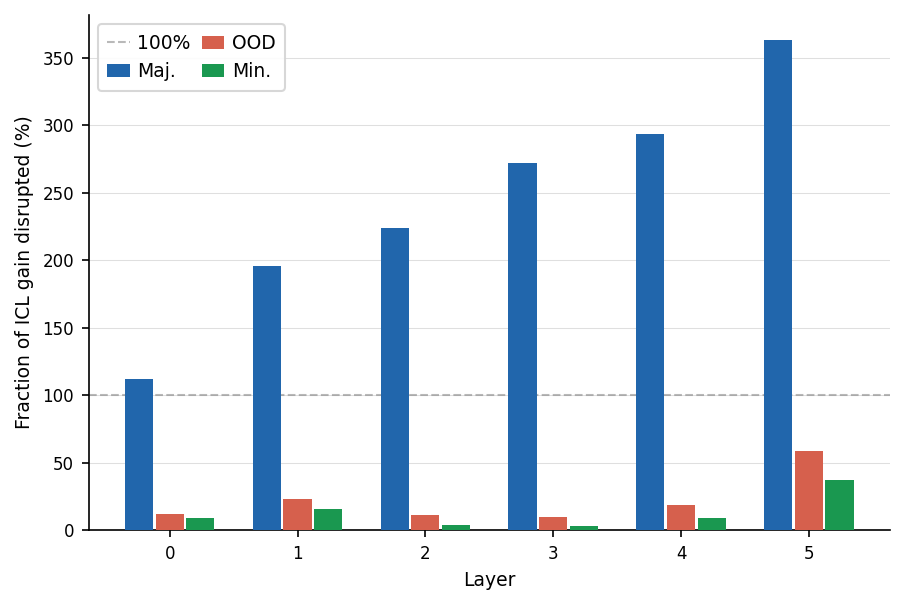


  Task Subspace Intervention — Δ𝓛/g (% of ICL gain)  [CE nats]
  ──────────────────────────────────────────────────────────────
  Layer    Maj.%     OOD%    Min.%  |    Maj.Δ    OOD Δ    Min.Δ
  ──────────────────────────────────────────────────────────────
      0    111.9%     11.6%      8.6%  |   0.1907   0.0366   0.0311
      1    195.9%     23.3%     15.9%  |   0.3338   0.0736   0.0571
      2    223.9%     10.9%      4.1%  |   0.3815   0.0343   0.0146
      3    272.4%     10.0%      2.9%  |   0.4643   0.0314   0.0105
      4    293.3%     18.7%      8.9%  |   0.4999   0.0589   0.0321
      5    363.6%     58.8%     37.3%  |   0.6196   0.1854   0.1345
  ──────────────────────────────────────────────────────────────
   Gain                                |   0.1704   0.3153   0.3603

  ─────────────────────────────────────────────────────────
  Layer-averaged (mean ± std across 6 layers) — CE nats
  ─────────────────────────────────────────────────────────
  Mode         Δ/g (%) 

In [2]:
from icl.coin.coin_analysis import plot_intervention_remove_task_across_layers_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", 10)
fig, results = plot_intervention_remove_task_across_layers_coin(
    exp_name=exp_name,
    n_samples_eval=2048,
    n_ood=1024,
    layers=range(6),
    # center_task_vecs=True,
    scale=1.5,
    figsize=(6, 4),
    show=True,
    save_path=None,
    extraction_point="post_mlp",
    probe_method="averaging",
)

2026-03-23 11:59:42 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 1 ...
2026-03-23 11:59:48 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 2 ...
2026-03-23 11:59:55 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 3 ...
2026-03-23 12:00:01 - icl.coin.analysis.interventions.remove_task - INFO - [task-removal sweep] layer 4 ...


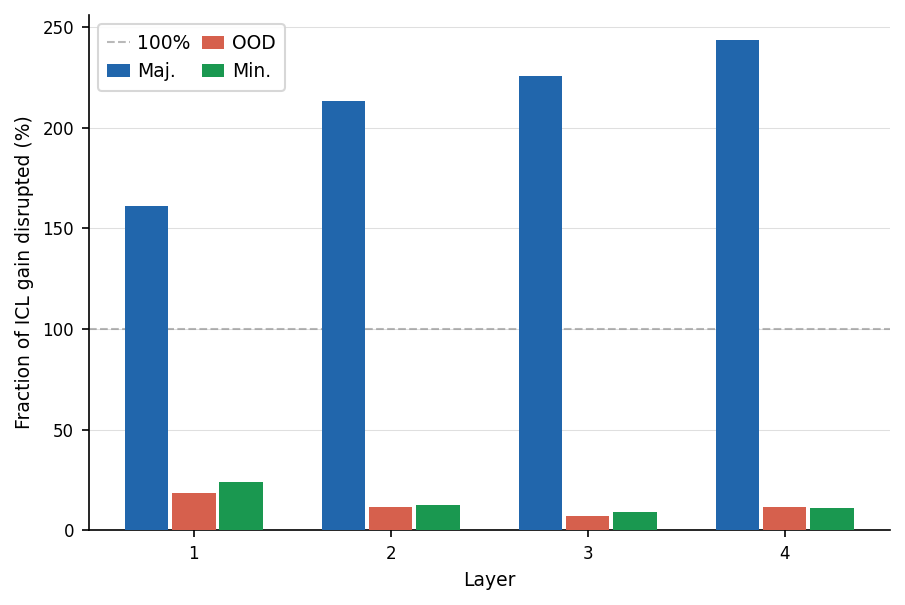


  Task Subspace Intervention — Δ𝓛/g (% of ICL gain)  [CE nats]
  ──────────────────────────────────────────────────────────────
  Layer    Maj.%     OOD%    Min.%  |    Maj.Δ    OOD Δ    Min.Δ
  ──────────────────────────────────────────────────────────────
      1    160.9%     18.4%     24.1%  |   0.2046   0.0639   0.0984
      2    213.4%     11.5%     12.5%  |   0.2714   0.0400   0.0509
      3    226.0%      7.0%      9.1%  |   0.2874   0.0242   0.0373
      4    243.9%     11.6%     11.2%  |   0.3102   0.0402   0.0458
  ──────────────────────────────────────────────────────────────
   Gain                                |   0.1272   0.3469   0.4084

  ─────────────────────────────────────────────────────────
  Layer-averaged (mean ± std across 4 layers) — CE nats
  ─────────────────────────────────────────────────────────
  Mode         Δ/g (%)         Raw Δ   g (CE nats)
  ─────────────────────────────────────────────────────────
  Maj.      211.1±30.9        0.2684        0.12

In [2]:
from icl.coin.coin_analysis import plot_intervention_remove_task_across_layers_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", 12)
fig, results = plot_intervention_remove_task_across_layers_coin(
    exp_name=exp_name,
    n_samples_eval=2048,
    n_ood=1024,
    layers=range(1,5),
    # center_task_vecs=True,
    scale=1.5,
    figsize=(6, 4),
    show=True,
    save_path=None,
    extraction_point="post_mlp",
    probe_method="averaging",
)

## Causal injection of task vectors

### Idea

If the task vectors $W_k$ truly encode task identity in the hidden state,
then *replacing* the task-subspace component of $\mathbf{h}$ with a
different task's vector should make the model behave as if it were
processing that other task.

### Intervention

For data generated under task $j$, the hook at layer $\ell$ performs:

$$
\mathbf{h}' = \mathbf{h} - P_{\mathrm{task}}\,\mathbf{h} + \mathbf{r}_k,
$$

where $P_{\mathrm{task}}$ is the projector onto the task subspace (from SVD
of $W$), and $\mathbf{r}_k$ is the reference vector for the *source* task
$k \neq j$.  This removes the original task component and injects task $k$'s
direction.

### Outputs (three figures)

1. **Task-ID accuracy heatmap** — for each (source $k$, target $j$) pair,
   does the model's output distribution shift to match task $k$?  Measured
   via argmax agreement with the source task's optimal prediction.
2. **KL divergence** — $\mathrm{KL}(p_{\mathrm{injected}} \| p_k)$: how
   close is the injected model's output to the source task's Bayes-optimal
   distribution?
3. **OOD injection** — inject each major task vector into OOD sequences and
   measure the resulting KL and loss shift.

2026-03-03 18:45:19 - icl.coin.analysis.interventions.inject_task - INFO - [inject sweep] layer 0 ...


INFO:icl.coin.analysis.interventions.inject_task:[inject sweep] layer 0 ...



Task-Vector Injection  (layer 0, scale=1.0)
  Task subspace rank: 2  |  K_major: 3
  Ref vecs: from probe W_k - W̄

  Major → Major injection:
  src→tgt    TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0→1           100.0%     0.0484    0.4636    0.5282    0.4212
  0→2           100.0%     0.0448    0.4953    0.4702    0.4403
  1→0            98.2%     0.4618    0.0417    0.5104    0.4386
  1→2           100.0%     0.4930    0.0360    0.4583    0.4308
  2→0            98.4%     0.4721    0.5172    0.0469    0.4296
  2→1            99.7%     0.5157    0.4718    0.0440    0.4202

  Major → OOD injection:
  src        TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0              100.0%     0.0253    0.5237    0.5405    0.1131
  1              100.0%     0.5243    0.0166    0.5297    0.0951
  2              100.0%     0.5318    0.5301    0.0238    0.

INFO:icl.coin.analysis.interventions.inject_task:[inject sweep] layer 1 ...



Task-Vector Injection  (layer 1, scale=1.0)
  Task subspace rank: 2  |  K_major: 3
  Ref vecs: from probe W_k - W̄

  Major → Major injection:
  src→tgt    TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0→1           100.0%     0.0479    0.4724    0.5307    0.4245
  0→2            99.7%     0.0450    0.5197    0.4925    0.4519
  1→0            99.7%     0.4770    0.0376    0.5274    0.4514
  1→2           100.0%     0.5175    0.0248    0.4882    0.4547
  2→0           100.0%     0.4938    0.5349    0.0395    0.4559
  2→1           100.0%     0.5293    0.4863    0.0359    0.4423

  Major → OOD injection:
  src        TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0              100.0%     0.0203    0.5375    0.5490    0.0880
  1              100.0%     0.5287    0.0134    0.5359    0.0996
  2              100.0%     0.5371    0.5365    0.0196    0.

...


Task-Vector Injection  (layer 3, scale=1.0)
  Task subspace rank: 2  |  K_major: 3
  Ref vecs: from probe W_k - W̄

  Major → Major injection:
  src→tgt    TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0→1           100.0%     0.0053    0.5266    0.5267    0.4828
  0→2           100.0%     0.0049    0.5298    0.5301    0.5022
  1→0           100.0%     0.5135    0.0050    0.5209    0.4835
  1→2           100.0%     0.5255    0.0042    0.5218    0.5045
  2→0           100.0%     0.5169    0.5232    0.0067    0.4814
  2→1           100.0%     0.5320    0.5294    0.0048    0.4891

  Major → OOD injection:
  src        TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0              100.0%     0.0055    0.5286    0.5300    0.1306
  1              100.0%     0.5211    0.0053    0.5226    0.0963
  2              100.0%     0.5296    0.5306    0.0059    0.

INFO:icl.coin.analysis.interventions.inject_task:[inject sweep] layer 4 ...



Task-Vector Injection  (layer 4, scale=1.0)
  Task subspace rank: 2  |  K_major: 3
  Ref vecs: from probe W_k - W̄

  Major → Major injection:
  src→tgt    TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0→1           100.0%     0.0066    0.5102    0.5154    0.4715
  0→2           100.0%     0.0060    0.5281    0.5153    0.4840
  1→0           100.0%     0.5211    0.0048    0.5159    0.5034
  1→2           100.0%     0.5179    0.0054    0.5099    0.4845
  2→0           100.0%     0.5350    0.5277    0.0048    0.4956
  2→1           100.0%     0.5292    0.5155    0.0058    0.4698

  Major → OOD injection:
  src        TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0              100.0%     0.0072    0.5147    0.5118    0.0887
  1              100.0%     0.5129    0.0063    0.5069    0.1120
  2              100.0%     0.5246    0.5156    0.0065    0.

INFO:icl.coin.analysis.interventions.inject_task:[inject sweep] layer 5 ...



Task-Vector Injection  (layer 5, scale=1.0)
  Task subspace rank: 2  |  K_major: 3
  Ref vecs: from probe W_k - W̄

  Major → Major injection:
  src→tgt    TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0→1           100.0%     0.0093    0.4986    0.4845    0.4682
  0→2           100.0%     0.0091    0.4937    0.4886    0.4529
  1→0           100.0%     0.4965    0.0078    0.4782    0.4787
  1→2           100.0%     0.4949    0.0074    0.4839    0.4494
  2→0           100.0%     0.5388    0.5273    0.0038    0.4946
  2→1           100.0%     0.5329    0.5295    0.0039    0.4851

  Major → OOD injection:
  src        TaskID acc      KL→t0     KL→t1     KL→t2     ΔLoss
  ------------------------------------------------------------
  0              100.0%     0.0109    0.4872    0.4793    0.0831
  1              100.0%     0.4950    0.0081    0.4800    0.0838
  2              100.0%     0.5305    0.5207    0.0049    0.

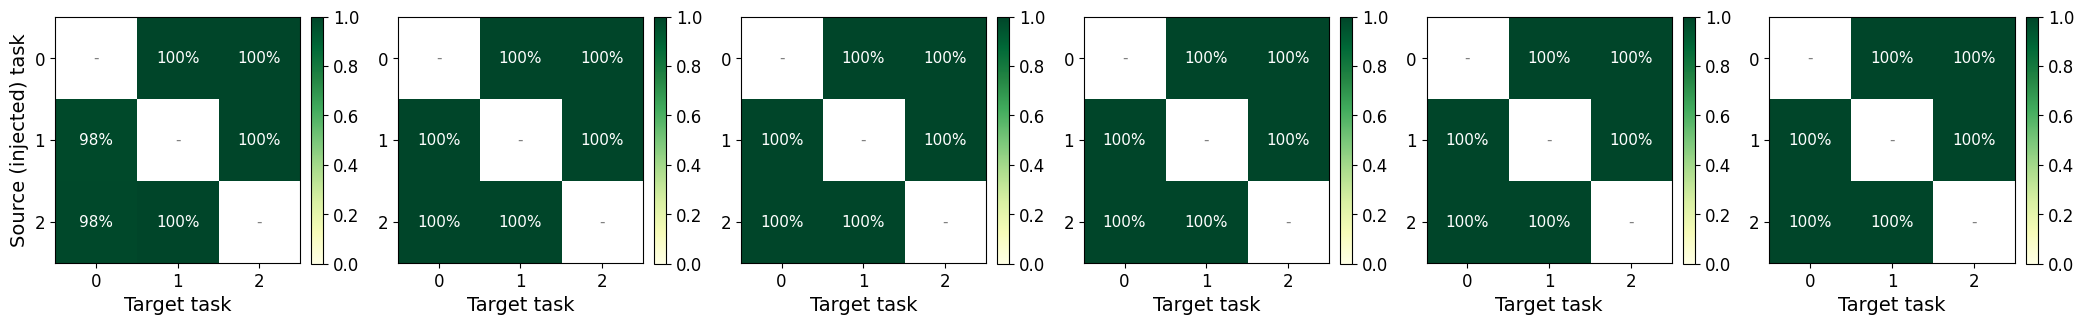

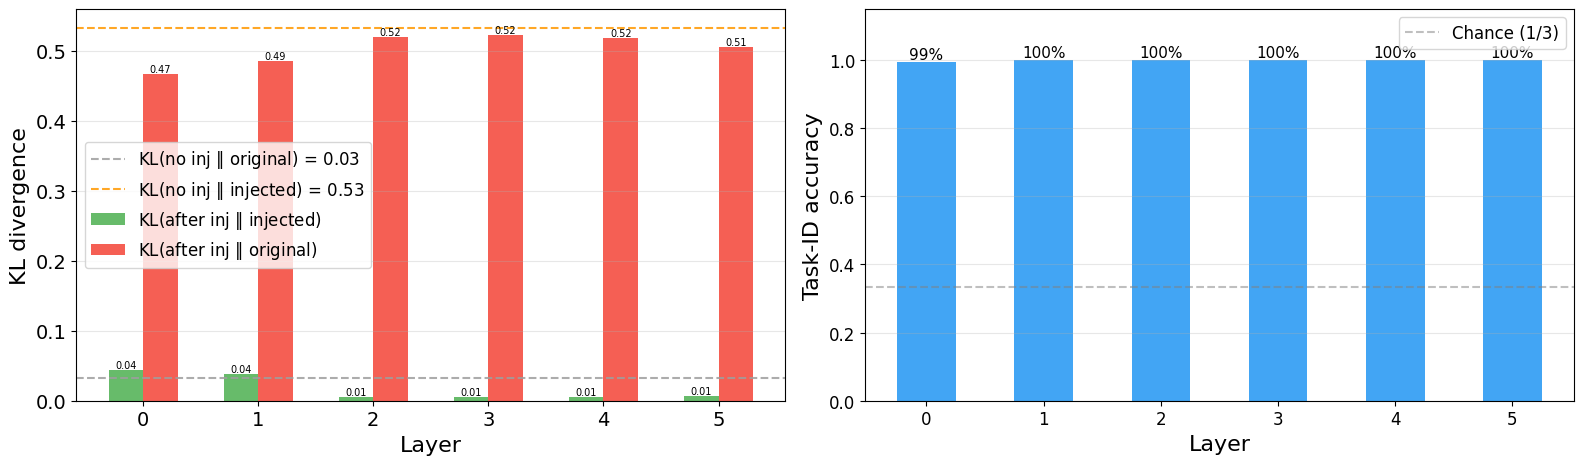

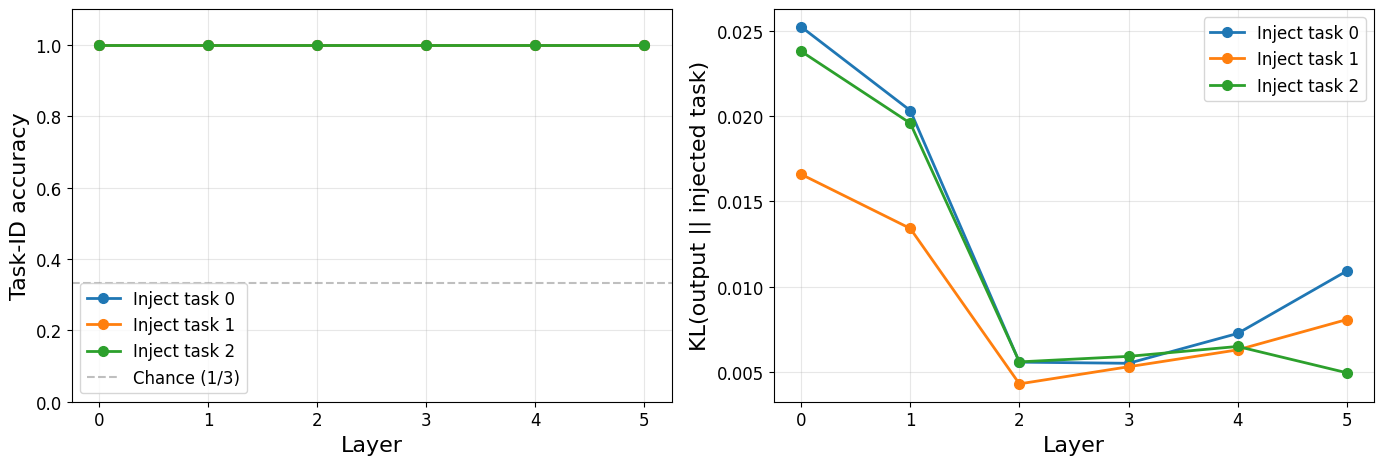

In [ ]:
from icl.coin.coin_analysis import plot_inject_task_vector_across_layers_coin
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("coin", -1, vocab_size=VOCAB_SIZE, major_pool_type=POOL_TYPE, major_means=MAJOR_MEANS)

fig_hm, fig_kl, fig_ood, all_results = plot_inject_task_vector_across_layers_coin(
    exp_name=exp_name,
    layers=range(6),
    n_samples_eval=1024,
    n_ood=64,
    fit_n_samples=4096,
    fit_positions=range(1, 25),           
    eval_positions=range(1, 25),
    center_task_vecs=True,
    scale=1.0,
)

---

## Task-Component Scaling Intervention

Does the **norm** of the task vector encode information, or only the **direction**?

Scale the task-subspace component of hidden states by a factor $c$:
$$h'_t = h_t + (c-1)\, P_{\text{task}}(h_t - \mu_t)$$
and measure how much the model output changes (KL divergence vs baseline).

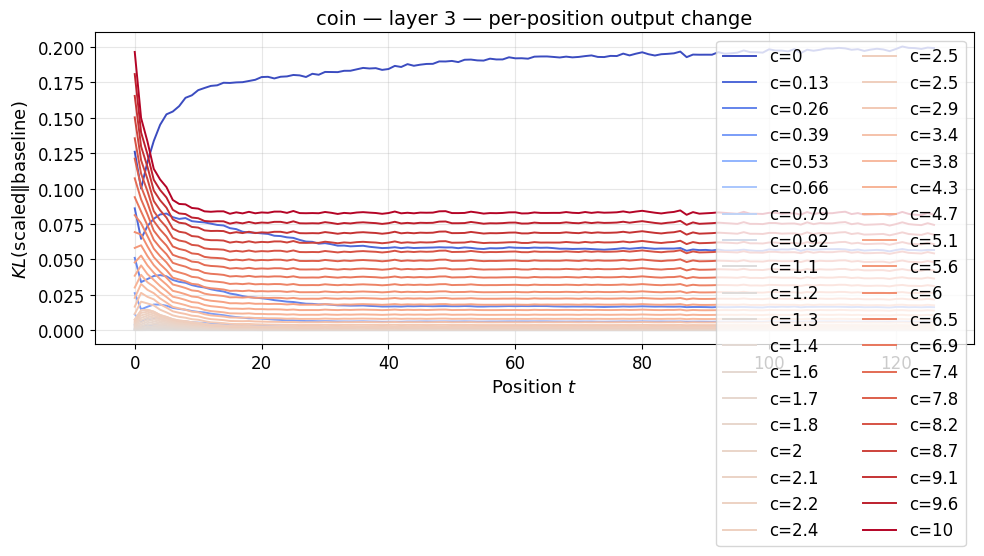

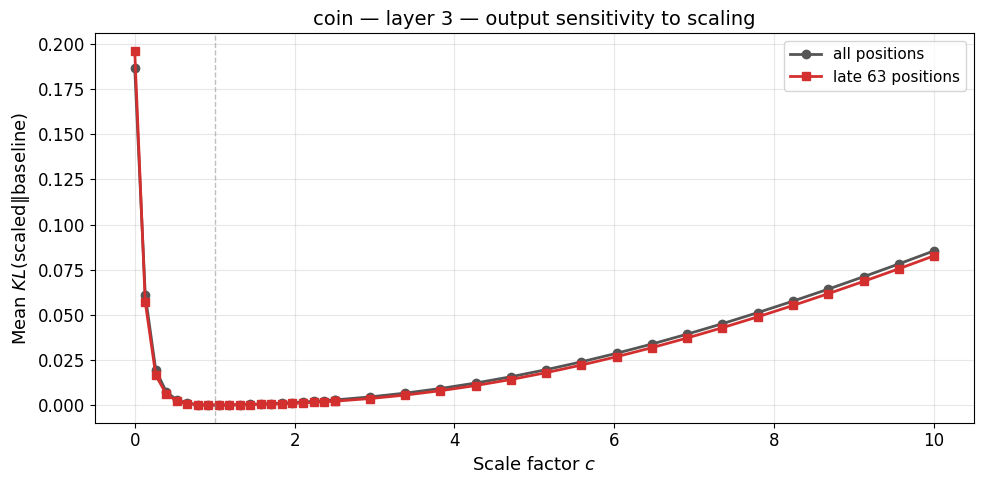

In [ ]:
import numpy as np
from icl.utils.unified_plot import intervene_scale_task_component
from icl.utils.unified_interface import get_exp_name

MAJOR_MEANS = [1.5, 2.5, 3.5]
VOCAB_SIZE = 6
POOL_TYPE = "partition"

exp_name = get_exp_name("coin", -1, vocab_size=VOCAB_SIZE, major_pool_type=POOL_TYPE, major_means=MAJOR_MEANS)

result = intervene_scale_task_component(
    "coin", exp_name,
    layer=3,
    scale_factors=np.concatenate([np.linspace(0, 2.5, 20), np.linspace(2.5, 10, 18)]).tolist(),
    B=64,
    n_samples=1000,
    estimation_B=128,
    per_position_mean=True,
    figsize=(10, 5),
)

## Residual Removal: Does projecting onto reference task+token subspace preserve model output?

Project each position's hidden state onto the **fixed reference subspace** (task vectors + token vectors estimated from late positions). If KL stays small even at early positions where R² is low, the residual is functionally unimportant.

[residual removal] layer=3, K=3, V=6, D=128
  reference subspace rank = 7
  estimation_positions = [25, 26, 27]..45


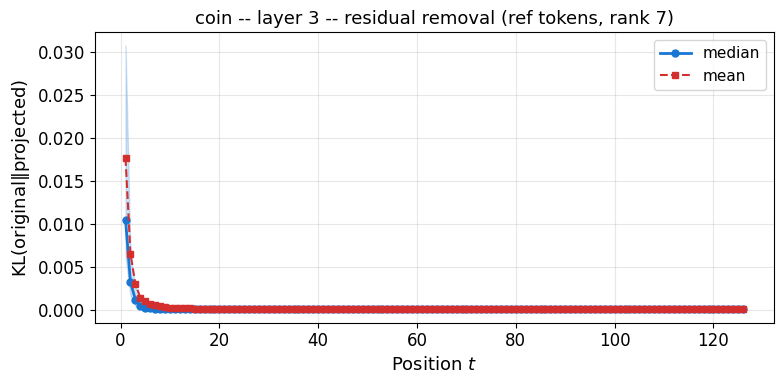


Residual Removal  (coin, layer 3)
  Token vectors: reference (pooled)
  Reference subspace rank = 7
  Overall mean KL(original || projected) = 0.000278
  Per-position mean KL range: [0.000011, 0.017598]



In [ ]:
from icl.utils.unified_plot import intervene_residual_removal
from icl.utils.unified_interface import get_exp_name

MAJOR_MEANS = [1.5, 2.5, 3.5]
VOCAB_SIZE = 6
POOL_TYPE = "partition"

exp_name = get_exp_name("coin", -1, vocab_size=VOCAB_SIZE, major_pool_type=POOL_TYPE, major_means=MAJOR_MEANS)

# Reference task vectors + reference (pooled) token vectors
result_ref = intervene_residual_removal(
    "coin", exp_name,
    layer=3,
    B=64,
    n_samples=2000,
    estimation_positions=list(range(25, 46)),
    estimation_B=128,
    per_position_mean=True,
    per_position_tokens=False,
    task_batch_size=8,
    marker_every=1,
    figsize=(8, 4),
    verbose=True,
)

[residual removal] layer=3, K=3, V=6, D=128
  per-position token vectors: rank range [7, 7]
  estimation_positions = [25, 26, 27]..45


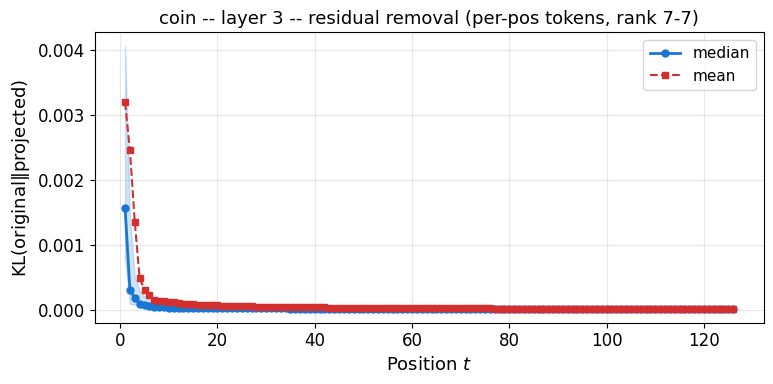


Residual Removal  (coin, layer 3)
  Token vectors: per-position
  Subspace rank range: [7, 7]
  Overall mean KL(original || projected) = 0.000094
  Per-position mean KL range: [0.000010, 0.003190]



In [ ]:
# Reference task vectors + per-position token vectors
result_ppt = intervene_residual_removal(
    "coin", exp_name,
    layer=3,
    B=64,
    n_samples=2000,
    estimation_positions=list(range(25, 46)),
    estimation_B=128,
    per_position_mean=True,
    per_position_tokens=True,
    task_batch_size=8,
    marker_every=1,
    figsize=(8, 4),
    verbose=True,
)